# Lithuanian Word List Processing Pipeline

This notebook processes multiple Lithuanian word count datasets to create clean, filtered word lists for the Word Square generator.

## 1. Data Aggregation
We begin by collecting word counts from various sources in the `data/` directory. All datasets are normalized to a standard `text` and `count` format.

In [ ]:
import pandas as pd

files = [
'data/aiana94_polynews/lithuanian_word_counts.tsv',
'data/ccll2_vs_war_in_UA/lithuanian_word_counts.tsv',
'data/common_voice_17/lithuanian_word_counts.tsv',
'data/community-datasets_tapaco/lithuanian_word_counts.tsv',
'data/Corpus_of_Discourse_on_Crime-LT/lithuanian_word_counts.tsv',
'data/DIGIRES_COVID19_LT/lithuanian_word_counts.tsv',
# 'data/DML6_vs_JCL/lithuanian_word_counts.tsv',
# 'data/EN-LT-FR_Parallel-corpus/lithuanian_word_counts.tsv',
'data/EN-LT_Comparable_Vaccination_corpus/lithuanian_word_counts.tsv',
'data/EN-LT_Parallel_CS_Corpus-v2/lithuanian_word_counts.tsv',
# 'data/etimologinio_zodyno_duomenu_baze/lithuanian_word_counts.tsv', +
# 'data/European Parliament Proceedings Parallel Corpus 1996-2011/lithuanian_word_counts.tsv',
# 'data/Fizinių_asmenų_bankrotas/lithuanian_word_counts.tsv', +
# 'data/grams/lithuanian_word_counts.tsv',
# 'data/HuggingFaceFW_finepdfs/lithuanian_word_counts.tsv',
# 'data/ispell-lt/lithuanian_word_counts.tsv', + 
# 'data/KLASIUS/lithuanian_word_counts.tsv',
# 'data/Lietuviu-kalbos-rasybos-tikrintuvai-bei-Hunspell-zodynai-gramatika/lithuanian_word_counts.tsv',
# 'data/Lithuanian Coreference Corpus/lithuanian_word_counts.tsv',
# 'data/Lithuanian-Hunspell-dictionary/lithuanian_word_counts.tsv', +
# 'data/Lithuanian-wordlist/lithuanian_word_counts.tsv',
# 'data/lithuanian-words-txt/lithuanian_word_counts.tsv',
'data/Lithuanian_Parliament_Corpus/lithuanian_word_counts.tsv',
'data/MATAS-v1.0/lithuanian_word_counts.tsv',
'data/mteb_biblenlp-corpus-mmteb/lithuanian_word_counts.tsv',
'data/PaDaS-Lab_webfaq/lithuanian_word_counts.tsv',
'data/qanastek_EMEA-V3/lithuanian_word_counts.tsv',
'data/scoris_en-lt-merged-data/lithuanian_word_counts.tsv',
# 'data/SkolintuZodynas/lithuanian_word_counts.tsv',
# 'data/vietovardziu_zodynas/lithuanian_word_counts.tsv',
'data/wikimediawikipedia/lithuanian_word_counts.tsv'
]

always_include = [
    'data/etimologinio_zodyno_duomenu_baze/lithuanian_word_counts.tsv',
    'data/Fizinių_asmenų_bankrotas/lithuanian_word_counts.tsv',
    'data/ispell-lt/lithuanian_word_counts.tsv',
    'data/Lithuanian-Hunspell-dictionary/lithuanian_word_counts.tsv',
]

dfs = []
for file in files:
    try:
        df = pd.read_csv(file, sep='\t', on_bad_lines='skip')
        # Rename columns to 'text' and 'count'
        if len(df.columns) >= 2:
            df = df.rename(columns={df.columns[0]: 'text', df.columns[1]: 'count'})
            dfs.append(df[['text', 'count']])
        else:
            print(f"Skipping {file}: unexpected number of columns")
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Combine all dataframes
combined_df = pd.concat(dfs, ignore_index=True)

# Group by 'text' and sum 'count'
combined_df = combined_df.groupby('text', as_index=False)['count'].sum()

# Sort by count descending
combined_df = combined_df.sort_values('count', ascending=False)

# Define Lithuanian letters
lithuanian_letters = set('aąbcčdeęėfghįiyjklmnoprsštuųūvzžAĄBCČDEĘĖFGHĮIYJKLMNOPRSŠTUŲŪVZŽ')

# Filter to keep only texts with Lithuanian letters only
combined_df = combined_df[combined_df['text'].apply(lambda x: all(c in lithuanian_letters for c in str(x)))]

# Display the combined dataframe
print("Combined word counts (Lithuanian letters only):")
print(combined_df.head(20))  # Show top 20

# Optionally save to a file
combined_df.to_csv('combined_word_counts.tsv', sep='\t', index=False)

Error reading data/EN-LT-FR_Parallel-corpus/lithuanian_word_counts.tsv: [Errno 2] No such file or directory: 'data/EN-LT-FR_Parallel-corpus/lithuanian_word_counts.tsv'
Error reading data/etimologinio_zodyno_duomenu_baze/lithuanian_word_counts.tsv: [Errno 2] No such file or directory: 'data/etimologinio_zodyno_duomenu_baze/lithuanian_word_counts.tsv'
Combined word counts (Lithuanian letters only):
         text    count
1044302    ir  3566829
1481411     m  1308807
1166577   kad  1249190
3113770   yra  1022216
3167775     į   870517
2670324    su   749478
1059474    iš   694141
2778970   tai   668368
490171   buvo   656271
1170549  kaip   527860
691028    dėl   474391
1919898   nuo   446203
244795     ar   434735
2780461  taip   423627
1955863     o   376443
212233   apie   347411
2503348  savo   338936
332189     aš   310304
1558937   mes   307611
564015      d   292790


## 2. Generate N-Letter Word Lists
After filtering the combined dataset for Lithuanian-only characters, we extract words of a specific length (e.g., $n=8$) to use in the generator. Row limits are applied to focus on the most common words.

In [2]:
import pandas as pd

# Load the combined word counts
combined_df = pd.read_csv('combined_word_counts.tsv', sep='\t')

n = 8

# Filter for n-letter words
eight_letter_words = combined_df[combined_df['text'].str.len() == n]['text']

# Take only top 100000 words
eight_letter_words = eight_letter_words.head(100000)

# Save to n_letters.txt
eight_letter_words.to_csv(f'{n}_letters.txt', index=False, header=False)

print(f"Saved {len(eight_letter_words)} {n}-letter words to {n}_letters.txt")
print(eight_letter_words.head(10))

Saved 100000 8-letter words to 8_letters.txt
39     lietuvos
70     įstatymo
98     Lietuvos
113    norėčiau
126    šiandien
128    istorija
132    komisija
134    nuorodos
144    sąjungos
151    pasakyti
Name: text, dtype: str


## 3. Letter Distribution Analysis
To optimize parallel processing, we analyze the frequency of words starting with each Lithuanian letter. This helps in balancing the workload across multiple threads.

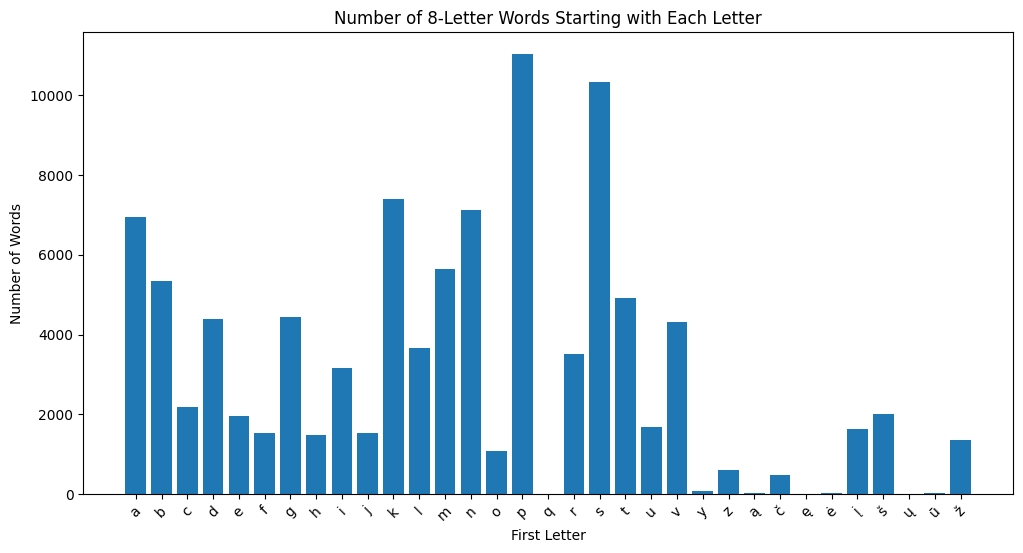

In [3]:
import matplotlib.pyplot as plt

# Read the file
with open(f'{n}_letters.txt', 'r', encoding='utf-8') as f:
    words = [line.strip() for line in f if line.strip()]

# Define the order of letters
letter_order = "abcdefghijklmnopqrstuvyząčęėįšųūž"

# Count words starting with each letter
counts = {letter: 0 for letter in letter_order}
for word in words:
    if word:
        first_letter = word[0].lower()
        if first_letter in counts:
            counts[first_letter] += 1

# Prepare data for plotting
letters = list(letter_order)
values = [counts[letter] for letter in letters]

# Plot the bar chart
plt.figure(figsize=(12, 6))
plt.bar(letters, values)
plt.xlabel('First Letter')
plt.ylabel('Number of Words')
plt.title(f'Number of {n}-Letter Words Starting with Each Letter')
plt.xticks(rotation=45)
plt.show()

## 4. Parallel Workload Distribution
Using a greedy approach, we partition the letters into four groups with roughly equal word counts. This balance is critical for efficient parallel execution of the Java application.

In [4]:
from collections import defaultdict

# Assuming letters and values are available from previous cells
# letters: list of letters
# values: list of counts corresponding to letters

# Pair letters with their values and sort by value descending
letter_value_pairs = sorted(zip(letters, values), key=lambda x: x[1], reverse=True)

# Initialize 4 groups as lists, and their current sums
groups = [[] for _ in range(4)]
group_sums = [0] * 4

# Greedily assign each letter to the group with the smallest current sum
for letter, value in letter_value_pairs:
    min_sum_index = group_sums.index(min(group_sums))
    groups[min_sum_index].append(letter)
    group_sums[min_sum_index] += value

# Print the groups and their sums for verification
for i, group in enumerate(groups):
    print(f"Group {i+1}: {group}, Sum: {group_sums[i]}")

# Now, if you want to split the words list based on first letter into these groups
word_groups = [[] for _ in range(4)]
for word in words:
    first_letter = word[0].lower()
    for i, group in enumerate(groups):
        if first_letter in group:
            word_groups[i].append(word)
            break

# word_groups now contains the split words
# For example, print lengths
for i, wg in enumerate(word_groups):
    print(f"Word group {i+1} length: {len(wg)}")

Group 1: ['p', 't', 'l', 'c', 'į', 'ž', 'y', 'q', 'ę', 'ų'], Sum: 24870
Group 2: ['s', 'b', 'v', 'š', 'j', 'o', 'č'], Sum: 25123
Group 3: ['k', 'm', 'g', 'r', 'e', 'f', 'z'], Sum: 25121
Group 4: ['n', 'a', 'd', 'i', 'u', 'h', 'ū', 'ą', 'ė'], Sum: 24886
Word group 1 length: 24870
Word group 2 length: 25123
Word group 3 length: 25121
Word group 4 length: 24886


In [5]:
# Print all group letters in one string
all_letters = ''.join(sum(groups, []))
print(all_letters)

ptlcįžyqęųsbvšjočkmgrefznadiuhūąė


In [6]:
count = 0
for letter in all_letters:
    print(f"{count}={letter}, ", end="")
    count += 1

0=p, 1=t, 2=l, 3=c, 4=į, 5=ž, 6=y, 7=q, 8=ę, 9=ų, 10=s, 11=b, 12=v, 13=š, 14=j, 15=o, 16=č, 17=k, 18=m, 19=g, 20=r, 21=e, 22=f, 23=z, 24=n, 25=a, 26=d, 27=i, 28=u, 29=h, 30=ū, 31=ą, 32=ė, 

## 5. Update Batch Script
This cell automatically updates the letter ranges in `run_parallel_by_ranges_update.bat` based on the balanced groups calculated above.

In [9]:
import re

# Map groups to start/end indices in the all_letters string
ranges = []
current_start = 0
for group in groups:
    group_len = len(group)
    ranges.append((current_start, current_start + group_len - 1))
    current_start += group_len

# Read the batch file
bat_path = 'run_parallel_by_ranges_update.bat'
with open(bat_path, 'r', encoding='utf-8') as f:
    bat_content = f.read()

# Update the launch commands using regex
# Matches: App_Parallelized <start> <end>
for i, (start, end) in enumerate(ranges):
    core_num = i + 1
    # Use non-indexed groups \g<1> and \g<2> to avoid ambiguity with the start digit
    pattern = rf'(App_Parallelized\s+)\d+\s+\d+(\s+>\s+log_core{core_num}\.txt)'
    replacement = rf'\g<1>{start} {end}\g<2>'
    bat_content = re.sub(pattern, replacement, bat_content)

# Write the updated content back
with open(bat_path, 'w', encoding='utf-8', newline='\r\n') as f:
    f.write(bat_content)

print("Updated run_parallel_by_ranges_update.bat with new ranges:")
for i, r in enumerate(ranges):
    print(f"Core {i+1}: {r[0]} to {r[1]}")

Updated run_parallel_by_ranges_update.bat with new ranges:
Core 1: 0 to 9
Core 2: 10 to 16
Core 3: 17 to 23
Core 4: 24 to 32
